Read CSV File

In [1]:
import pandas as pd

# Load the CSV using a relative path from the notebook
df = pd.read_csv('../data/vv_data_20250722.csv')

print(df.shape)
df.head()

(1044, 23)


,Unnamed: 0,uid,price,suv_prob,vert_prob,sedan_prob,coupe_prob,hatchback_prob,window_damage_prob,door_damage_prob,...,average_cond_prob,year,make,model_name,trim,mileage,title_status,transmission,engine_cylinders,displacement
0,0,7865789467,1800.0,0.475830,0.511719,0.736328,0.074585,0.422119,0.457275,0.240845,...,0.200439,2003,Honda,Accord EX,EX,NaN,NaN,Automatic,NaN,NaN
1,1,7865784701,2800.0,0.186523,0.113647,0.741211,0.034515,0.250977,0.120483,0.157104,...,0.128296,2003,Honda,Accord,NaN,NaN,NaN,NaN,NaN,NaN
2,2,7865780123,1999.0,0.412354,0.242432,0.717773,0.027008,0.605957,0.320801,0.520508,...,0.392090,2000,Accord,Lx,NaN,159000,NaN,Needs repair/replace (current one is going out),NaN,NaN
3,3,7865763347,6995.0,0.137573,0.114441,0.713379,0.083740,0.314941,0.418457,0.186279,...,0.188599,2010,Honda,Accord LX Sedan 4-DOORS,LX,105000,clean,Automatic,4,2.4
4,4,7865716774,22000.0,0.622070,0.347656,0.853516,0.156128,0.516113,0.452393,0.161377,...,0.570801,18,Accord,Sport,NaN,81100,clean,NaN,NaN,NaN



Calculate Average Price and Listing Count for Each Make-Model

In [3]:
# Group by make and model_name, compute average price and listing count
summary = (
    df.groupby(['make', 'model_name'])
      .agg(avg_price=('price', 'mean'),
           listing_count=('uid', 'count'))
      .reset_index()
      .sort_values(by=['make', 'model_name'])
)

# Display results
summary.head(20)
summary.to_csv('../data/avg_price_by_make_model.csv', index=False)


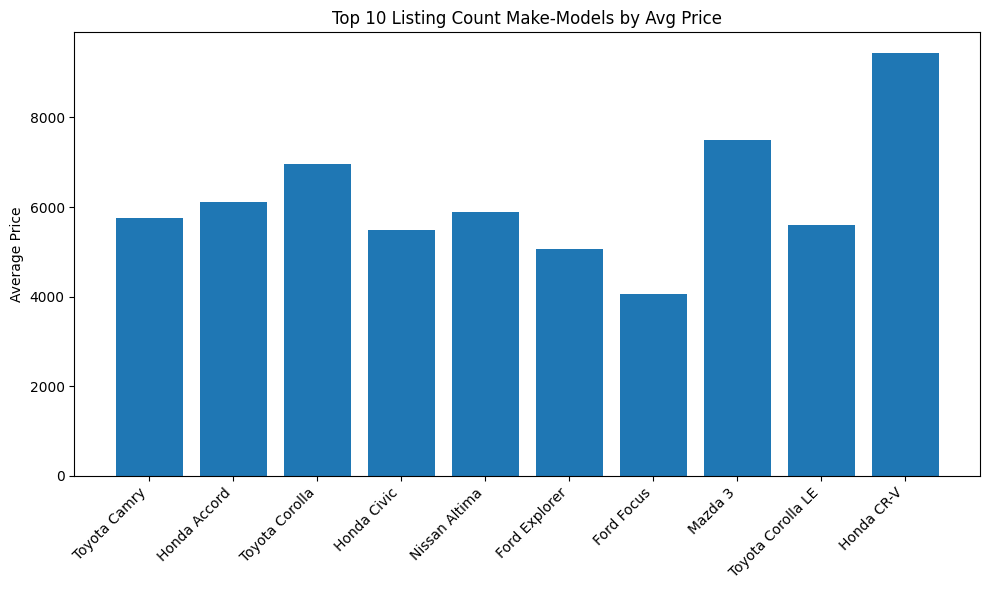

In [5]:
import matplotlib.pyplot as plt

# Combine make and model_name into a single label for plotting
summary['make_model'] = summary['make'] + ' ' + summary['model_name']

# Sort by listing count, take top 10
top10 = summary.sort_values('listing_count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10['make_model'], top10['avg_price'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Price')
plt.title('Top 10 Listing Count Make-Models by Avg Price')
plt.tight_layout()
plt.show()


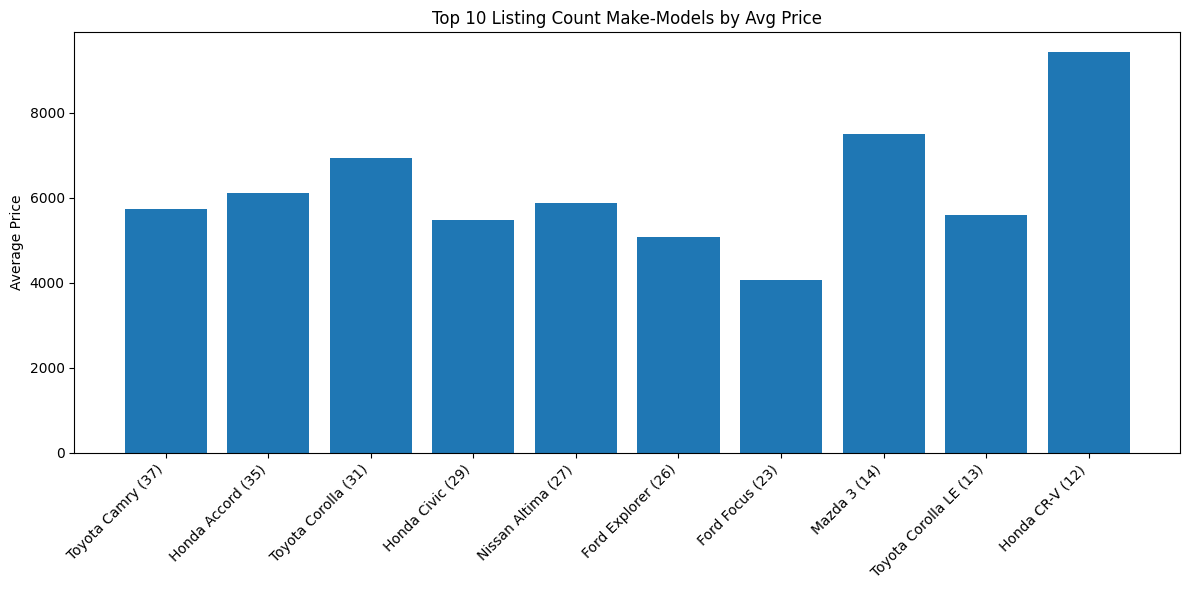

In [6]:
# Add listing count to label
top10['label'] = top10['make_model'] + ' (' + top10['listing_count'].astype(str) + ')'

plt.figure(figsize=(12, 6))
bars = plt.bar(top10['label'], top10['avg_price'])

plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Price')
plt.title('Top 10 Listing Count Make-Models by Avg Price')
plt.tight_layout()
plt.show()


See Distribution of Car Condition Against Price for Top 10 Listing Make-Model

In [7]:
top10_make_models = (
    summary.sort_values('listing_count', ascending=False)
    .head(10)[['make', 'model_name']]
)

# Merge to keep only rows from top 10 make-models
top10_df = df.merge(top10_make_models, on=['make', 'model_name'])


In [8]:
def condition_label(prob):
    if prob >= 0.8:
        return 'Excellent'
    elif prob >= 0.5:
        return 'Good'
    elif prob >= 0.2:
        return 'Fair'
    else:
        return 'Poor'

top10_df['condition'] = top10_df['excellent_cond_prob'].apply(condition_label)


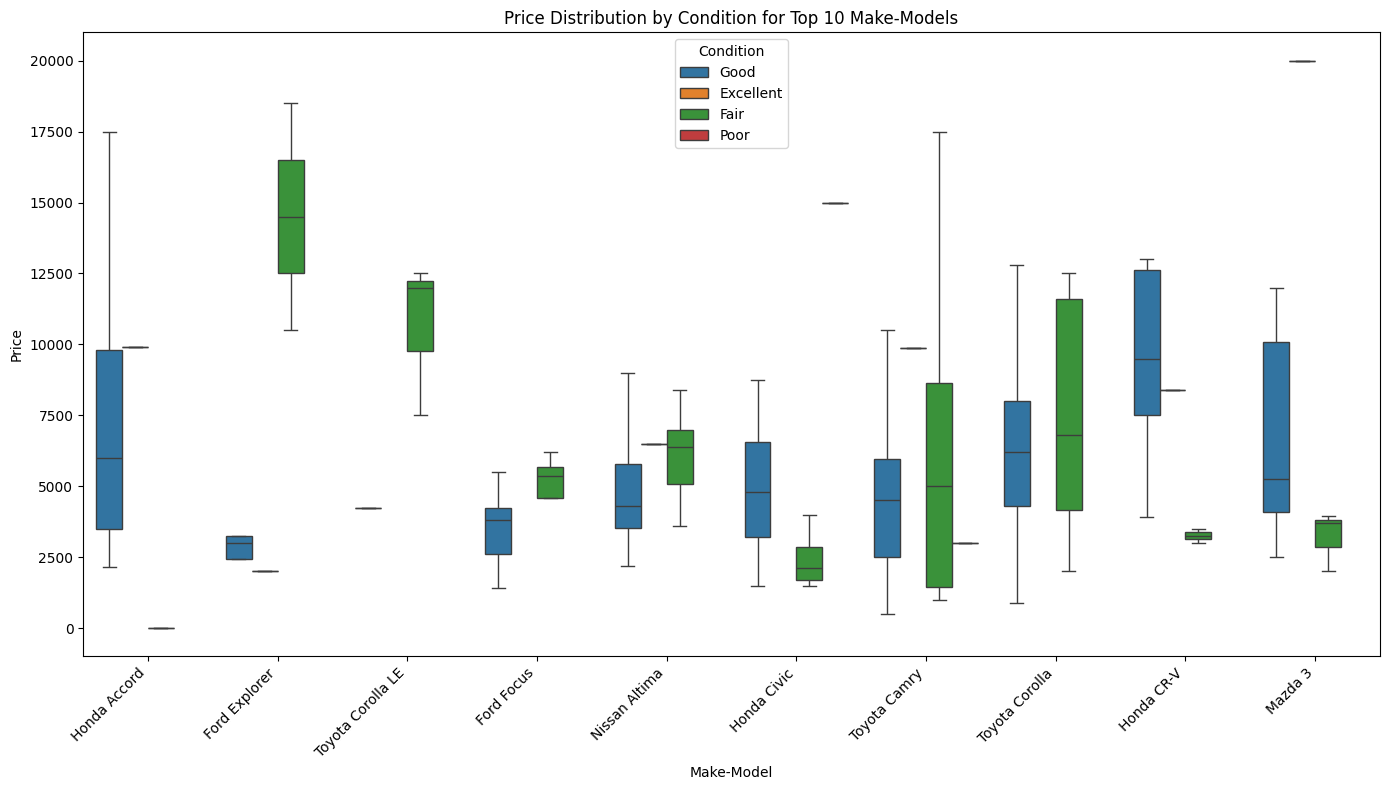

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine make and model for plot labels
top10_df['make_model'] = top10_df['make'] + ' ' + top10_df['model_name']

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=top10_df,
    x='make_model',
    y='price',
    hue='condition',
    showfliers=False
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Price')
plt.xlabel('Make-Model')
plt.title('Price Distribution by Condition for Top 10 Make-Models')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


For each of the excellence category, get mean, mode, median to see the distrubition of average price

In [28]:
import pandas as pd
from scipy.stats import mode

print(df['price'].dtype)
print(top10_df['price'].dtype)


# Group by make_model and condition, then aggregate
def robust_mode(x):
    print("MODE INPUT:", x.tolist())
    m = x.mode()
    if not m.empty:
        return m.iloc[0]
    return x.iloc[0] if len(x) == 1 else None

def robust_median(x):
    print("MEDIAN INPUT:", x.tolist())
    if len(x) == 1:
        return x.iloc[0]
    return x.median()

agg = (
    top10_df.groupby(['make_model', 'condition'])
      .agg(
          mean_price=('price', 'mean'),
          median_price=('price', lambda x: float(x.iloc[0]) if len(x) == 1 else float(x.median())),
          mode_price=('price', lambda x: float(x.iloc[0]) if len(x) == 1 else (float(x.mode().iloc[0]) if not x.mode().empty else None)),
          count=('price', 'count')
      )
      .reset_index()
      .sort_values(['make_model', 'condition'])
)


agg


# Display results
agg



float64
float64


,make_model,condition,mean_price,median_price,mode_price,count
0,Ford Explorer,Excellent,2000.000000,2000.0,2000.0,1
1,Ford Explorer,Fair,14500.000000,14500.0,10500.0,2
2,Ford Explorer,Good,4388.913043,3000.0,3250.0,23
3,Ford Focus,Fair,4925.000000,5350.0,2800.0,4
4,Ford Focus,Good,3875.736842,3799.0,3999.0,19
5,Honda Accord,Excellent,9900.000000,9900.0,9900.0,1
6,Honda Accord,Fair,1400.600000,1.0,1.0,5
7,Honda Accord,Good,6789.482759,6000.0,2200.0,29
8,Honda CR-V,Excellent,8400.000000,8400.0,8400.0,1
9,Honda CR-V,Fair,3250.000000,3250.0,3000.0,2


In [29]:
print(top10_df[(top10_df['make_model'] == 'Honda Accord') & (top10_df['condition'] == 'Fair')][['price']])


      price
15   6999.0
31      1.0
133     1.0
134     1.0
190     1.0


In [17]:
agg.to_csv('../data/top10_make_model_condition_stats.csv', index=False)

Apply the same categorization for all records

In [18]:
def condition_label(prob):
    if prob >= 0.8:
        return 'Excellent'
    elif prob >= 0.5:
        return 'Good'
    elif prob >= 0.2:
        return 'Fair'
    else:
        return 'Poor'

df['condition'] = df['excellent_cond_prob'].apply(condition_label)

In [19]:
agg_all = (
    df.groupby(['make', 'model_name', 'condition'])
      .agg(
          mean_price=('price', 'mean'),
          median_price=('price', 'median'),
          mode_price=('price', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
          count=('price', 'count')
      )
      .reset_index()
      .sort_values(['make', 'model_name', 'condition'])
)

In [20]:
agg_all.to_csv('../data/all_make_model_condition_stats.csv', index=False)